# Denoinsing with PCA or MNF (minimum noise fraction)

In [3]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils import *
import numpy as np
import hyperspy.api as hs
import os
import matplotlib.pyplot as plt
import copy
from skimage.metrics import peak_signal_noise_ratio as psnr
from importlib import reload
from EDX import *
from datetime import datetime
from sklearn.metrics import silhouette_samples
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import tifffile as tif
from skimage import data, img_as_float
from bm3d import bm3d

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Sanity demo for BM3D

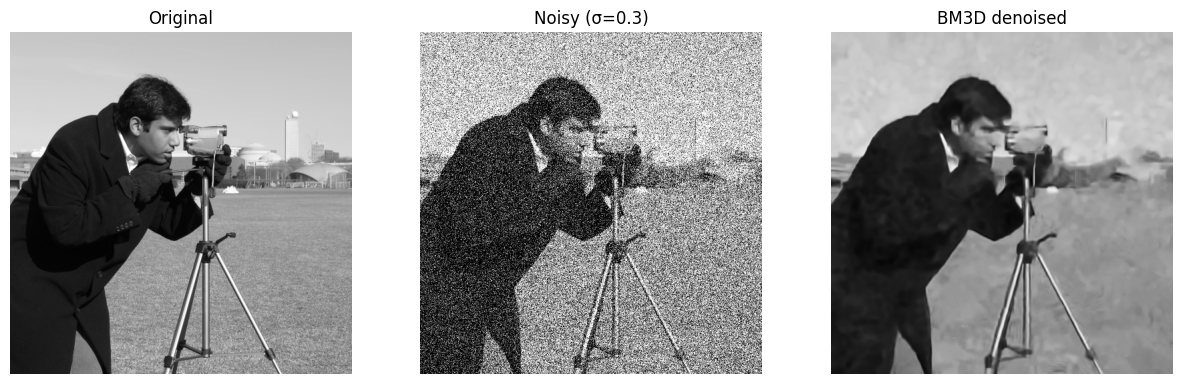

In [10]:
# Load a stock grayscale image (0–1 float)
img = img_as_float(data.camera())  

# Add synthetic Gaussian noise
sigma = 0.30      # noise std 
noisy = img + sigma * np.random.randn(*img.shape)
noisy = np.clip(noisy, 0, 1)

# Apply BM3D denoising
denoised = bm3d(noisy, sigma)

# Show results
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(img, cmap='gray')
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(noisy, cmap='gray')
ax[1].set_title(f"Noisy (σ={sigma})")
ax[1].axis("off")

ax[2].imshow(denoised, cmap='gray')
ax[2].set_title("BM3D denoised")
ax[2].axis("off")

plt.show()

#### get masks

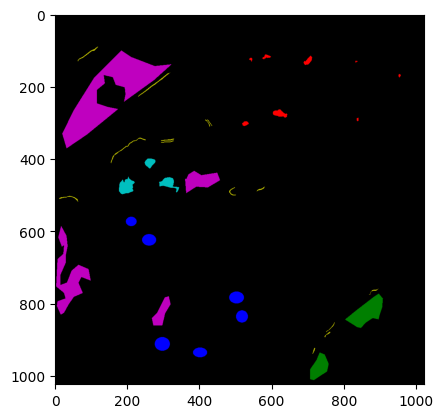

In [11]:
# get the hand-annotated masks and display them
mask_dir = os.path.join(os.path.dirname(os.getcwd()),'data', 'masks')
masks = create_masks(mask_dir)
colors = ['k','r','g','b','c','m','y']
newcmap = ListedColormap(colors)
plt.imshow(masks,cmap=newcmap)
plt.show()

### load data

In [26]:
# load data
file_path = "../data/EMD/EDXdataset.emd"

# Create results folder with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = f"./results/{timestamp}"
os.makedirs(results_dir, exist_ok=True)

# load and save the 100 frame NPS
edx, haadf, xray_energies = load_EDX(file_path, first_frame=0, last_frame=20, sum_frames=True)
tile = EM_EDX(haadf, edx, xray_energies)
tile.apply("crop", parameters={"crop_idx": (slice(None), slice(None), slice(96, 4096))})
tile.apply("binning", parameters={"dim": (1024, 1024, 250)})
tile.apply("MeanFilterEDX", parameters={"kernel_size": 3})


WARNING | RosettaSciIO | The file contains only one spectrum stream (rsciio.emd._emd_velox:590)


<EM_EDX | 3 steps logged>

### Apply pca+bm3d

In [34]:
tile_pca_bm3d = tile.apply("PCA_bm3d", parameters={"k": 10, "sigma": 0.1},copy_instance=True)


In [36]:
# compute sil scores for both
sil_img = sil_scores(tile.EDX, masks, metric='cosine')
sil_img2 = sil_scores(tile_pca_bm3d.EDX, masks, metric='cosine')

# compute global vmin/vmax 
vmin = np.nanmin(np.array([sil_img,sil_img2]))
vmax = np.nanmax(np.array([sil_img,sil_img2]))

/var/folders/77/2p3cpr_n18s6qc_nxslbsp3r0000gn/T/ipykernel_9039/1746182088.py:17: UserWarning: Adding colorbar to a different Figure <Figure size 1500x1500 with 5 Axes> than <Figure size 1500x500 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.2,location='top')


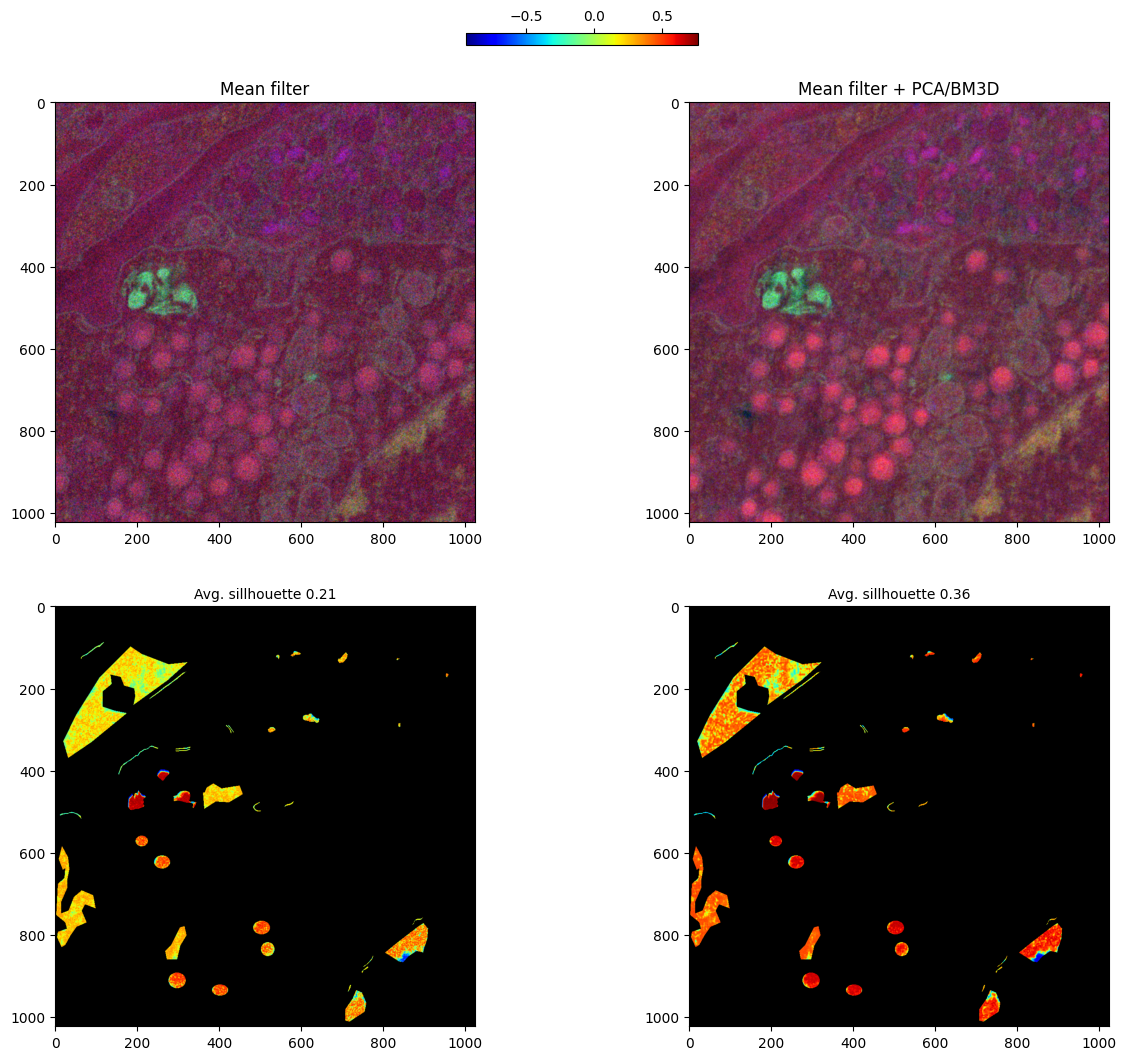

In [40]:
# modify jet so NaNs appear black
cmap = plt.cm.jet.copy()
cmap.set_bad(color='black')

f, ax = plt.subplots(2,2,figsize=(15, 15))
ax[0][0].imshow(tile.FalseColor())
ax[0][0].set_title('Mean filter')
ax[0][1].imshow(tile_pca_bm3d.FalseColor())
ax[0][1].set_title('Mean filter + PCA/BM3D')

im = ax[1][0].imshow(sil_img,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][0].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img),fontsize=10)
im = ax[1][1].imshow(sil_img2,cmap=cmap,vmin=vmin,vmax=vmax)
ax[1][1].set_title("Avg. sillhouette %.2f" % np.nanmean(sil_img2),fontsize=10)

# one shared colorbar
fig.colorbar(im, ax=ax.ravel().tolist(), shrink=0.2,location='top')

#plt.tight_layout()
plt.show()

plt.show()